# PyTorch3d: Просмотр меша и генерация датасета

В этом ноутбуке показано, как:
- загрузить меш и текстуры из файла `.obj`;
- создать синтетический датасет, отрендерив текстурированный меш с нескольких точек обзора;

См. полный ноутбук здесь: https://github.com/facebookresearch/pytorch3d/blob/main/docs/tutorials/fit_textured_mesh.ipynb

## 0. Установка и импорт модулей

Убедитесь, что `torch` и `torchvision` установлены. Если `pytorch3d` не установлен, установите его с помощью следующей ячейки:

In [2]:
import os
import sys
import torch
import subprocess
need_pytorch3d=False
try:
    import pytorch3d
except ModuleNotFoundError:
    need_pytorch3d=True
if need_pytorch3d:
    pyt_version_str=torch.__version__.split("+")[0].replace(".", "")
    version_str="".join([
        f"py3{sys.version_info.minor}_cu",
        torch.version.cuda.replace(".",""),
        f"_pyt{pyt_version_str}"
    ])
    !pip install iopath
    if sys.platform.startswith("linux"):
        print("Пробуем установить wheel для PyTorch3D")
        !pip install --no-index --no-cache-dir pytorch3d -f https://dl.fbaipublicfiles.com/pytorch3d/packaging/wheels/{version_str}/download.html
        pip_list = !pip freeze
        need_pytorch3d = not any(i.startswith("pytorch3d==") for  i in pip_list)
    if need_pytorch3d:
        print(f"Не удалось найти/установить wheel для {version_str}")
if need_pytorch3d:
    print("Устанавливаем PyTorch3D из исходников")
    !pip install ninja
    !pip install 'git+https://github.com/facebookresearch/pytorch3d.git@stable'

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=93685b65f81f71ded480ee64c65ca4f1018df8f8b1ee51c68194f59f39a77562
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built iopath
Пробуем установить wheel для PyTorch3D
Looking in links: https://dl.fbaipublicfiles.com/pytorch3d/packaging/wheels/py312_cu128_pyt2100/download.html
ERROR: Could not find a version that satisfies the requirement pytorch3d (from versions: none)
ERROR: No matching distribution found for pytorch3d
Не удалось найти/установить wheel для py312_cu128_pyt2100
Устанавливаем PyTorch3D из исходников
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 7.3 MB/s eta 0:00:00
  Cloning https://github.com/facebookresearch/pytorch3d.git (to revision stable) to /tmp/pip-req-build-rls58p0k
  Running c

In [7]:
# Для последующего быстрого восстановления

import os
import shutil
from google.colab import files

# Находим где установлен pytorch3d
!pip show pytorch3d

# Создаем архив всей директории site-packages с pytorch3d
!tar -czf pytorch3d_backup.tar.gz -C /usr/local/lib/python3.12/dist-packages/ pytorch3d

# Проверяем размер
!ls -lh pytorch3d_backup.tar.gz

# Скачиваем архив
files.download('pytorch3d_backup.tar.gz')

Name: pytorch3d
Version: 0.7.8
Summary: PyTorch3D is FAIR's library of reusable components for deep Learning with 3D data.
Home-page: https://github.com/facebookresearch/pytorch3d
Author: FAIR
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: iopath
Required-by: 
-rw-r--r-- 1 root root 64M Mar 12 08:14 pytorch3d_backup.tar.gz


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
import os
import torch
import matplotlib.pyplot as plt

from pytorch3d.utils import ico_sphere
import numpy as np
from tqdm.notebook import tqdm

# Вспомогательная функция для загрузки мешей
from pytorch3d.io import load_objs_as_meshes, save_obj

from pytorch3d.loss import (
    chamfer_distance,
    mesh_edge_loss,
    mesh_laplacian_smoothing,
    mesh_normal_consistency,
)

# Структуры данных и функции для рендеринга
from pytorch3d.structures import Meshes
from pytorch3d.renderer import (
    look_at_view_transform,
    FoVPerspectiveCameras,
    PointLights,
    DirectionalLights,
    Materials,
    RasterizationSettings,
    MeshRenderer,
    MeshRasterizer,
    SoftPhongShader,
    SoftSilhouetteShader,
    SoftPhongShader,
    TexturesVertex
)

# Добавим путь к вспомогательным функциям для демо
import sys
import os
sys.path.append(os.path.abspath(''))

Если вы используете **Google Colab**, загрузите вспомогательный файл для построения сетки изображений:

In [11]:
!wget https://raw.githubusercontent.com/facebookresearch/pytorch3d/main/docs/tutorials/utils/plot_image_grid.py
from plot_image_grid import image_grid

--2026-03-12 08:19:18--  https://raw.githubusercontent.com/facebookresearch/pytorch3d/main/docs/tutorials/utils/plot_image_grid.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1608 (1.6K) [text/plain]
Saving to: ‘plot_image_grid.py.1’

plot_image_grid.py. 100%[===================>]   1.57K  --.-KB/s    in 0s      

2026-03-12 08:19:18 (34.0 MB/s) - ‘plot_image_grid.py.1’ saved [1608/1608]



ИЛИ, если вы запускаете ноутбук **локально**, раскомментируйте и выполните следующую ячейку:

In [5]:
# from utils.plot_image_grid import image_grid

## 1. Загрузка меша и файла текстуры

Загрузим файл `.obj` и связанный с ним файл `.mtl`, а затем создадим объекты **Textures** и **Meshes**.

**Meshes** — это специальная структура данных PyTorch3D для работы с батчами мешей разных размеров.

**TexturesVertex** — вспомогательная структура данных для хранения RGB-текстур по вершинам меша.

У класса **Meshes** есть несколько методов, которые используются далее по всему пайплайну рендеринга.

Данные: https://github.com/facebookresearch/pytorch3d/tree/main/docs/tutorials/data/cow_mesh

Если вы запускаете этот ноутбук в **Google Colab**, выполните следующую ячейку, чтобы загрузить `.obj`-файл меша и файлы текстур и сохранить их по пути `data/cow_mesh`:

Если вы запускаете ноутбук локально, данные уже доступны по правильному пути.

In [6]:
!mkdir -p data/cow_mesh
!wget -P data/cow_mesh https://dl.fbaipublicfiles.com/pytorch3d/data/cow_mesh/cow.obj
!wget -P data/cow_mesh https://dl.fbaipublicfiles.com/pytorch3d/data/cow_mesh/cow.mtl
!wget -P data/cow_mesh https://dl.fbaipublicfiles.com/pytorch3d/data/cow_mesh/cow_texture.png

--2026-03-12 07:03:25--  https://dl.fbaipublicfiles.com/pytorch3d/data/cow_mesh/cow.obj
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.163.189.14, 3.163.189.51, 3.163.189.108, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.163.189.14|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 330659 (323K) [text/plain]
Saving to: ‘data/cow_mesh/cow.obj’

cow.obj             100%[===================>] 322.91K  --.-KB/s    in 0.02s   

2026-03-12 07:03:25 (13.0 MB/s) - ‘data/cow_mesh/cow.obj’ saved [330659/330659]

--2026-03-12 07:03:25--  https://dl.fbaipublicfiles.com/pytorch3d/data/cow_mesh/cow.mtl
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 3.163.189.14, 3.163.189.51, 3.163.189.108, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|3.163.189.14|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 155 [text/plain]
Saving to: ‘data/cow_mesh/cow.mtl’

cow.mtl             100%[=======

In [12]:
# Настройка
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    torch.cuda.set_device(device)
else:
    device = torch.device("cpu")

# Зададим пути
DATA_DIR = "./data"
obj_filename = os.path.join(DATA_DIR, "cow_mesh/cow.obj")

# Загрузим OBJ-файл
mesh = load_objs_as_meshes([obj_filename], device=device)

In [13]:
mesh

In [14]:
mesh.verts_packed()

tensor([[ 0.3488, -0.3350, -0.0832],
        [ 0.3131, -0.3991,  0.8812],
        [ 0.2668,  0.1816,  0.1227],
        ...,
        [-0.0132, -0.0889,  1.0422],
        [-0.0137, -0.0943,  1.0340],
        [-0.0137, -0.0796,  1.0469]], device='cuda:0')

In [15]:
# Нормализуем масштаб и центрируем целевой меш так, чтобы он помещался в сферу радиуса 1
# с центром в точке (0,0,0). Параметры (scale, center) затем понадобятся, чтобы вернуть предсказанный меш
# к исходному масштабу и исходному положению. Заметьте, что нормализация целевого меша
# ускоряет оптимизацию, но не является обязательной!
verts = mesh.verts_packed()
N = verts.shape[0]
center = verts.mean(0)
scale = max((verts - center).abs().max(0)[0])
mesh.offset_verts_(-center)
mesh.scale_verts_((1.0 / float(scale)));

## 2. Создание датасета

Мы выбираем разные положения камер, соответствующие нескольким точкам обзора коровы. Затем создаём рендерер с шейдером, который выполняет интерполяцию текстурной карты. После этого рендерим синтетический датасет изображений текстурированного меша коровы с разных ракурсов.

In [16]:
# Число разных точек обзора, из которых мы хотим отрендерить меш.
num_views = 20

# Получим батч углов обзора.
elev = torch.linspace(0, 360, num_views) # elevation, угол возвышения
azim = torch.linspace(-180, 180, num_views) # азимут, то есть поворот вокруг объекта

# Разместим точечный источник света перед объектом. Как уже отмечалось выше, передняя часть
# коровы направлена вдоль оси -z.
lights = PointLights(device=device, location=[[0.0, 0.0, -3.0]])

In [8]:
# Инициализируем перспективную камеру OpenGL, которая представляет батч разных
# углов обзора. Все вспомогательные методы для камер поддерживают смешанные типы входов и
# broadcasting. Поэтому мы можем задать расстояние до камеры dist=2.7, а
# затем указать углы возвышения и азимута для каждой точки обзора как тензоры.
R, T = look_at_view_transform(dist=2.7, elev=elev, azim=azim)
cameras = FoVPerspectiveCameras(device=device, R=R, T=T)

# Произвольно выберем один конкретный ракурс, который будем использовать для визуализации
# результатов
camera = FoVPerspectiveCameras(device=device, R=R[None, 1, ...],
                                  T=T[None, 1, ...])

# Зададим параметры растеризации и шейдинга. Здесь мы устанавливаем выходное
# изображение размером 128x128. Поскольку мы рендерим изображения только для визуализации,
# мы зададим faces_per_pixel=1 и blur_radius=0.0. Подробности по этим параметрам см. в
# файле rasterize_meshes.py. Также оставим
# bin_size и max_faces_per_bin равными их значениям по умолчанию None; это
# позволяет выбрать их эвристически и гарантирует использование более быстрого метода растеризации coarse-to-fine.
# О различии между naive и coarse-to-fine растеризацией см.
# docs/notes/renderer.md.
raster_settings = RasterizationSettings(
    image_size=128,
    blur_radius=0.0,
    faces_per_pixel=1,
)

# Создадим рендерер Фонга, составив его из растеризатора и шейдера. Текстурированный
# шейдер Фонга будет интерполировать UV-координаты текстуры для каждой вершины,
# брать значения из изображения текстуры и применять модель освещения Фонга
renderer = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=camera,
        raster_settings=raster_settings
    ),
    shader=SoftPhongShader(
        device=device,
        cameras=camera,
        lights=lights
    )
)

# Создадим батч мешей, повторив меш коровы и связанные с ним текстуры.
# У объекта Meshes есть удобный метод `extend`, который позволяет сделать это очень просто.
# Он также дублирует текстуры.
meshes = mesh.extend(num_views)

# Отрендерим меш коровы с каждого ракурса
target_images = renderer(meshes, cameras=cameras, lights=lights)

Визуализируем датасет:

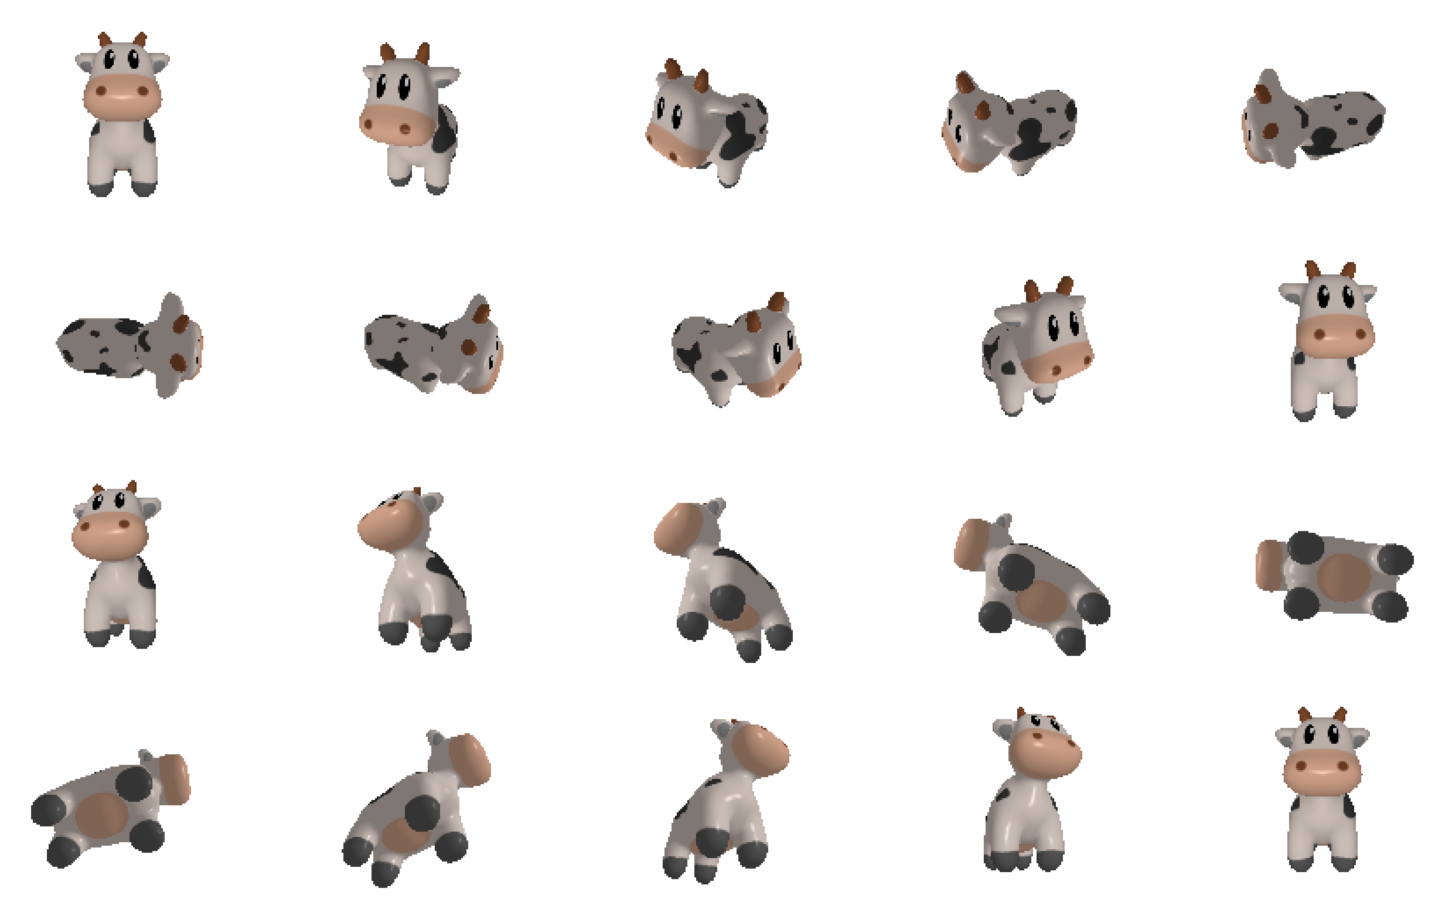

In [9]:
# RGB-изображения
image_grid(target_images.cpu().numpy(), rows=4, cols=5, rgb=True)
plt.show()

In [ ]:
# Наш датасет коровы с несколькими точками обзора будет представлен этими двумя списками тензоров,
# каждый длины num_views.
target_rgb = [target_images[i, ..., :3] for i in range(num_views)]
target_cameras = [FoVPerspectiveCameras(device=device, R=R[None, i, ...],
                                           T=T[None, i, ...]) for i in range(num_views)]

Позже в этом ноутбуке мы будем подгонять меш как по отрендеренным RGB-изображениям, так и только по изображениям силуэта коровы. Для второго случая мы отдельно отрендерим датасет силуэтов. Большинство шейдеров в PyTorch3D возвращают вместе с RGB-изображением ещё и альфа-канал как 4-й канал в RGBA-изображении. Альфа-канал кодирует вероятность того, что каждый пиксель принадлежит переднему плану объекта. Мы используем мягкий шейдер силуэта, чтобы отрендерить этот альфа-канал.

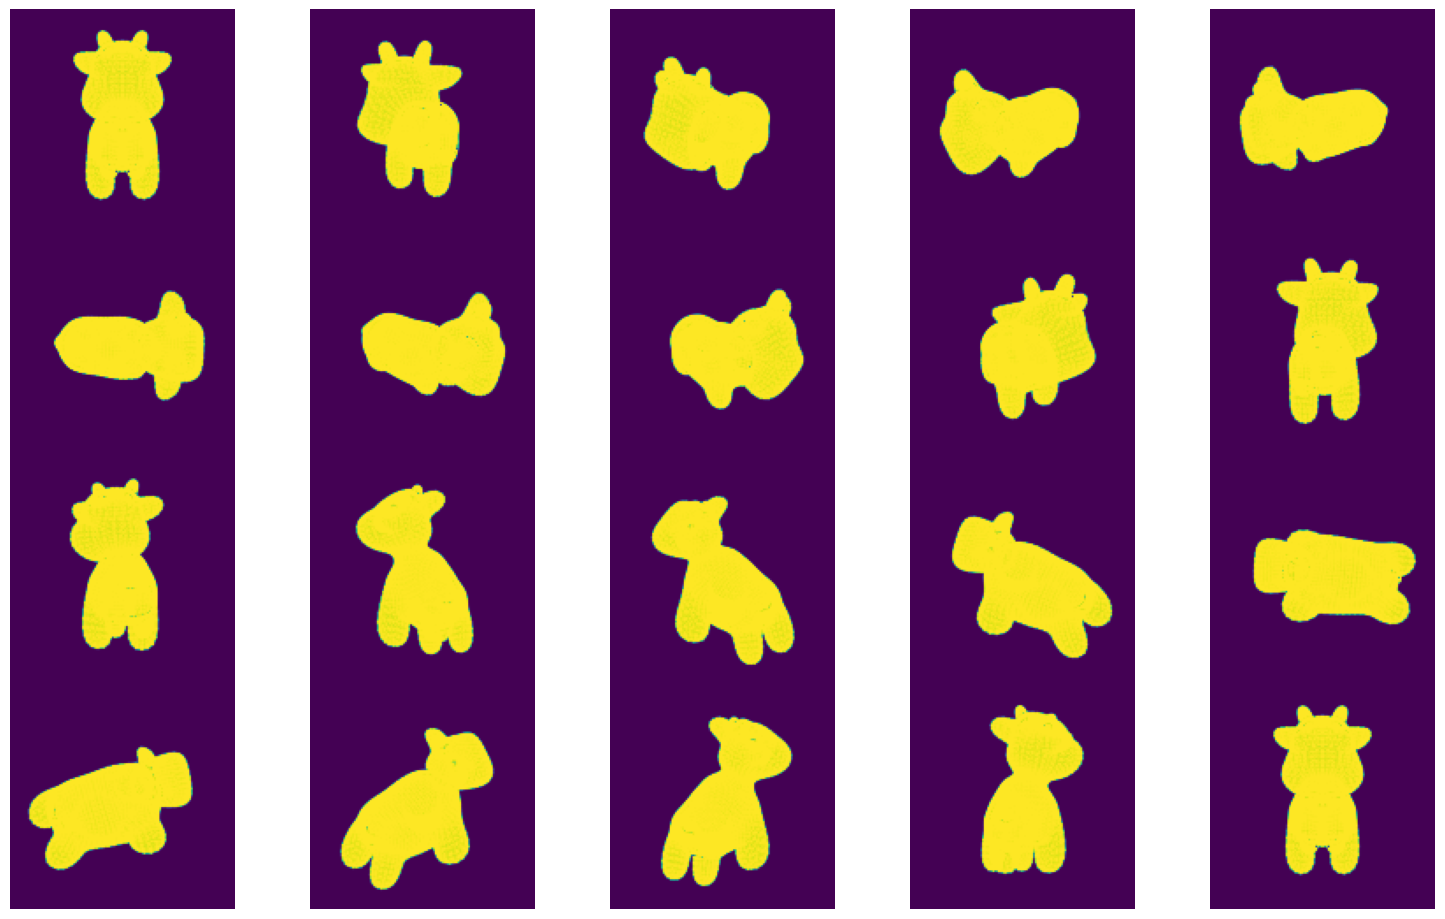

In [10]:
# Параметры растеризации для рендеринга силуэта
sigma = 1e-4
raster_settings_silhouette = RasterizationSettings(
    image_size=128,
    blur_radius=np.log(1. / 1e-4 - 1.)*sigma,
    faces_per_pixel=50,
)

# Рендерер силуэта
renderer_silhouette = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=camera,
        raster_settings=raster_settings_silhouette
    ),
    shader=SoftSilhouetteShader()
)

# Отрендерим изображения силуэта. Третий канал результата рендеринга — это
# альфа-канал / канал силуэта
silhouette_images = renderer_silhouette(meshes, cameras=cameras, lights=lights)

# Визуализируем изображения силуэта
image_grid(silhouette_images.cpu().numpy(), rows=4, cols=5, rgb=False)
plt.show()

In [ ]:
target_silhouette = [silhouette_images[i, ..., 3] for i in range(num_views)]